In [22]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt

In [23]:
X_train = np.load("../dataset/X_train.npy")
y_train = np.load("../dataset/y_train.npy")

X_val = np.load("../dataset/X_val.npy")
y_val = np.load("../dataset/y_val.npy")

X_test = np.load("../dataset/X_test.npy")
y_test = np.load("../dataset/y_test.npy")

In [24]:
# Convert to tensor
X_train = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)
X_val = torch.tensor(X_val, dtype=torch.float32).permute(0, 3, 1, 2)
X_test = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

## Experiment 1: Activation Comparison

In [25]:
class BottleCNN(nn.Module):
    def __init__(self, activation='relu'):
        super(BottleCNN, self).__init__()

        def get_act():
            if activation == 'relu':
                return nn.ReLU()
            elif activation == 'sigmoid':
                return nn.Sigmoid()
            elif activation == 'tanh':
                return nn.Tanh()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            get_act(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            get_act(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            get_act(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            get_act(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [26]:
def train_model(model, optimizer, epochs=10):
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()

        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val)
            val_losses.append(val_loss.item())

    return train_losses, val_losses

**ReLU**

In [27]:
model_relu = BottleCNN(activation='relu')
optimizer = torch.optim.Adam(model_relu.parameters(), lr=0.001)

relu_train, relu_val = train_model(model_relu, optimizer)

**Sigmoid**

In [28]:
model_sigmoid = BottleCNN(activation='sigmoid')
optimizer = torch.optim.Adam(model_sigmoid.parameters(), lr=0.001)

sig_train, sig_val = train_model(model_sigmoid, optimizer)

**Tanh**

In [29]:
model_tanh = BottleCNN(activation='tanh')
optimizer = torch.optim.Adam(model_tanh.parameters(), lr=0.001)

tanh_train, tanh_val = train_model(model_tanh, optimizer)

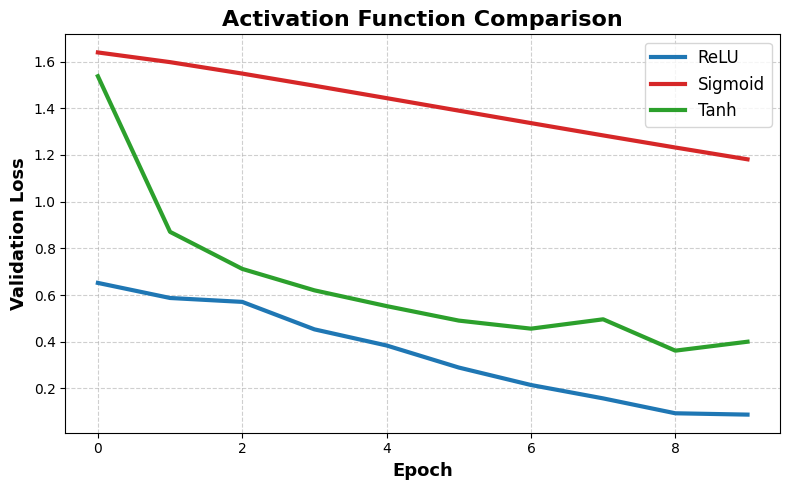

In [31]:
plt.figure(figsize=(8,5))

plt.plot(relu_val, label="ReLU", linewidth=3, color="#1f77b4")
plt.plot(sig_val, label="Sigmoid", linewidth=3, color="#d62728")
plt.plot(tanh_val, label="Tanh", linewidth=3, color="#2ca02c")

plt.xlabel("Epoch", fontsize=13, fontweight='bold')
plt.ylabel("Validation Loss", fontsize=13, fontweight='bold')
plt.title("Activation Function Comparison", fontsize=16, fontweight='bold')

plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Experiment 2: Optimizer Comparison

In [61]:
def train_model_batch(model, optimizer, epochs=10):
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for X_batch, y_batch in train_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_losses.append(total_loss / len(train_loader))

        # Validation
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()

        val_losses.append(val_loss / len(val_loader))

        print(f"Epoch {epoch+1}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")

    return train_losses, val_losses

In [62]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

**Adam**

In [63]:
model_adam = BottleCNN()
optimizer_adam = torch.optim.Adam(model_adam.parameters(), lr=0.001)

adam_train, adam_val = train_model_batch(model_adam, optimizer_adam)

Epoch 1, Train Loss: 0.9157, Val Loss: 0.7074
Epoch 2, Train Loss: 0.6898, Val Loss: 0.6738
Epoch 3, Train Loss: 0.6710, Val Loss: 0.6225
Epoch 4, Train Loss: 0.5566, Val Loss: 0.4577
Epoch 5, Train Loss: 0.3637, Val Loss: 0.2099
Epoch 6, Train Loss: 0.2401, Val Loss: 0.1168
Epoch 7, Train Loss: 0.1517, Val Loss: 0.0523
Epoch 8, Train Loss: 0.0811, Val Loss: 0.0192
Epoch 9, Train Loss: 0.0607, Val Loss: 0.0229
Epoch 10, Train Loss: 0.0429, Val Loss: 0.0088


**SGD**

In [66]:
model_sgd = BottleCNN()
optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.9)

sgd_train, sgd_val = train_model_batch(model_sgd, optimizer_sgd)

Epoch 1, Train Loss: 0.6911, Val Loss: 0.6797
Epoch 2, Train Loss: 0.6834, Val Loss: 0.6538
Epoch 3, Train Loss: 0.6368, Val Loss: 0.5828
Epoch 4, Train Loss: 0.5610, Val Loss: 0.4413
Epoch 5, Train Loss: 0.5464, Val Loss: 0.4375
Epoch 6, Train Loss: 0.4527, Val Loss: 0.3271
Epoch 7, Train Loss: 0.3771, Val Loss: 0.2559
Epoch 8, Train Loss: 0.3564, Val Loss: 0.2592
Epoch 9, Train Loss: 0.3218, Val Loss: 0.1712
Epoch 10, Train Loss: 0.2035, Val Loss: 0.1204


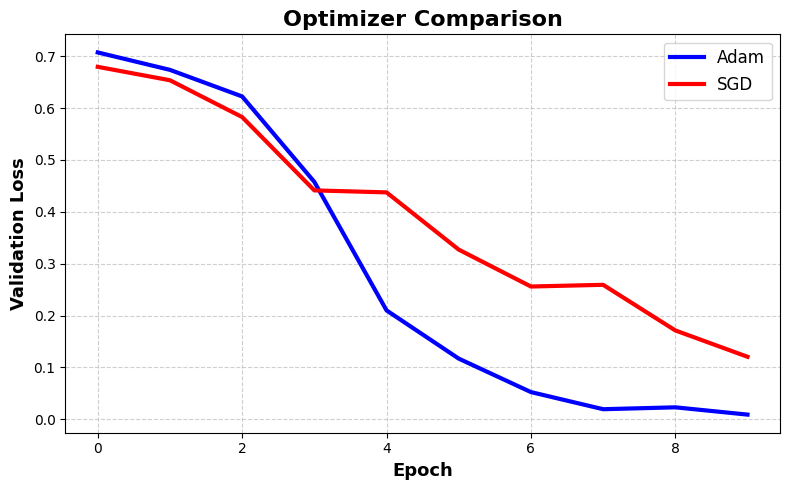

In [75]:
import matplotlib.pyplot as plt

plt.style.use('default')  # IMPORTANT: resets any style

plt.figure(figsize=(8,5))

plt.plot(adam_val, label="Adam", linewidth=3, color="blue")
plt.plot(sgd_val, label="SGD", linewidth=3, color="red")

plt.xlabel("Epoch", fontsize=13, fontweight='bold')
plt.ylabel("Validation Loss", fontsize=13, fontweight='bold')
plt.title("Optimizer Comparison", fontsize=16, fontweight='bold')

plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()